In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

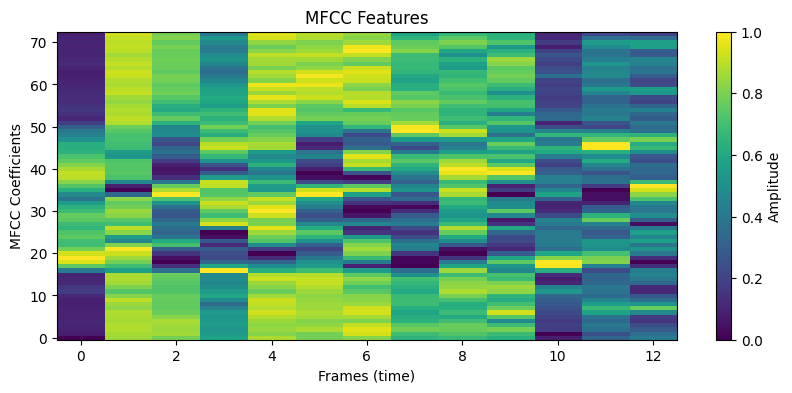

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Load fitur dari file .npy
mfcc = np.load("../../Dataset/Acoustic_Features/eval/MFCC/1001_DFA_DIS_XX_mfcc.npy")

plt.figure(figsize=(10, 4))
plt.imshow(mfcc, aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Amplitude")
plt.title("MFCC Features")
plt.xlabel("Frames (time)")
plt.ylabel("MFCC Coefficients")
plt.show()


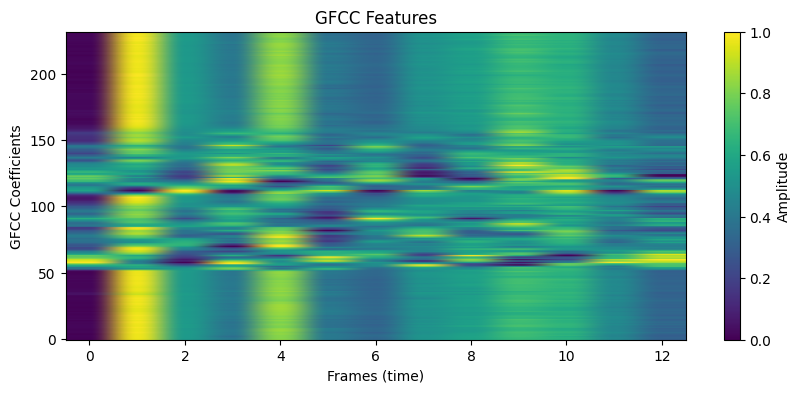

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load fitur dari file .npy
gfcc = np.load("../../Dataset/Acoustic_Features/eval/GFCC/1001_DFA_DIS_XX_gfcc.npy")

plt.figure(figsize=(10, 4))
plt.imshow(gfcc, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label="Amplitude")
plt.title("GFCC Features")
plt.xlabel("Frames (time)")
plt.ylabel("GFCC Coefficients")
plt.show()

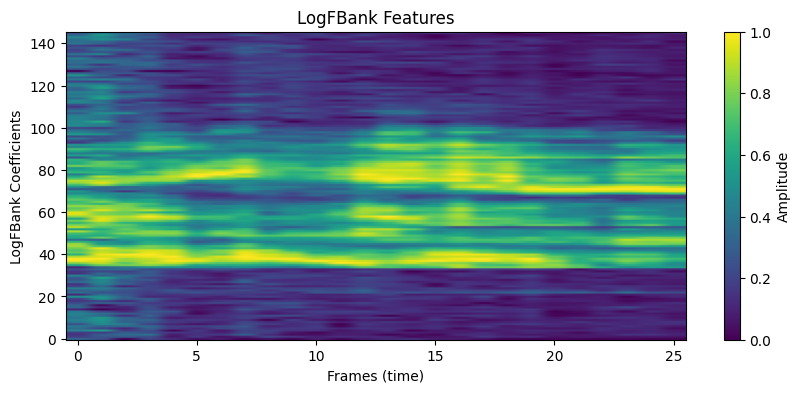

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Load fitur dari file .npy
logfbank = np.load("../../Dataset/Acoustic_Features/eval/LogFBank/1001_DFA_DIS_XX_logfbank.npy")

plt.figure(figsize=(10, 4))
plt.imshow(logfbank, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label="Amplitude")
plt.title("LogFBank Features")
plt.xlabel("Frames (time)")
plt.ylabel("LogFBank Coefficients")
plt.show()


TypeError: Invalid shape (128,) for image data

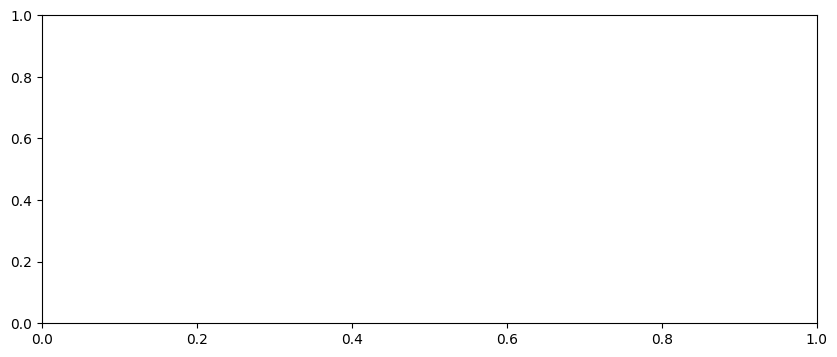

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load fitur dari file .npy
lstm = np.load("Dataset/LSTM_Features/train/1001_DFA_ANG_XX_summary.npy")

plt.figure(figsize=(10, 4))
plt.imshow(lstm, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label="Amplitude")
plt.title("GFCC Features")
plt.xlabel("Frames (time)")
plt.ylabel("GFCC Coefficients")
plt.show()


In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ---------------- Config ----------------
summary_dir = "Dataset/Temporal_Features/test/MFCC"  # ganti sesuai fitur & split
csv_path = "Dataset/CSV/test_split_stress.csv"       # labelnya

# ---------------- Load Label ----------------
df = pd.read_csv(csv_path)  # isi: filename, actor, sentence, emotion, pitch, stress
label_map = {lab: idx for idx, lab in enumerate(df["emotion"].unique())}  # mapping label ke angka

X, y = [], []
for i, row in df.iterrows():
    fname = row["filename"]
    emotion = row["emotion"]

    summary_path = os.path.join(summary_dir, f"{fname}_summary.npy")
    if os.path.exists(summary_path):
        feat = np.load(summary_path)
        X.append(feat)
        y.append(label_map[emotion])

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)  # (N, hidden_dim)

# ---------------- PCA ----------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 5))
for lab, idx in label_map.items():
    plt.scatter(X_pca[y == idx, 0], X_pca[y == idx, 1], label=lab, alpha=0.7)
plt.legend()
plt.title("PCA Visualization of LSTM Summary Features")
plt.show()

# ---------------- t-SNE ----------------
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(6, 5))
for lab, idx in label_map.items():
    plt.scatter(X_tsne[y == idx, 0], X_tsne[y == idx, 1], label=lab, alpha=0.7)
plt.legend()
plt.title("t-SNE Visualization of LSTM Summary Features")
plt.show()


Working dir: C:\personal\coding\hadi_skripsi\Scripts\Visualizer
Resolved csv_path: C:\Personal\coding\hadi_skripsi\Dataset\CSV\test_split_stress.csv
Found features: 0 / 744 rows
Found files: 0
Missing files: 744


FileNotFoundError: Tidak ditemukan fitur summary (.npy). Periksa summary_dir dan nama berkas pada CSV.

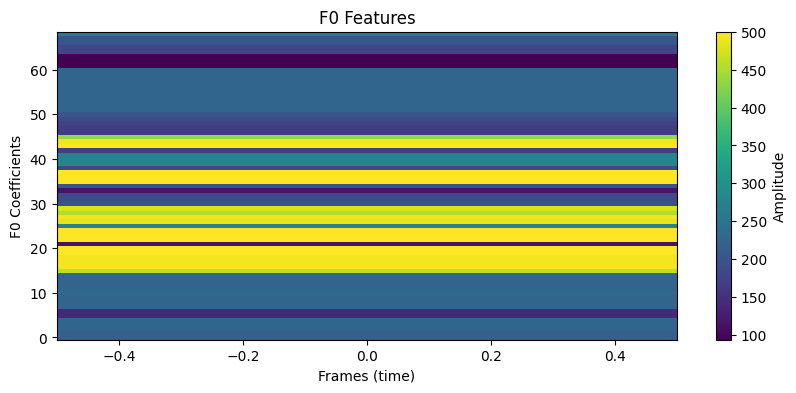

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Load fitur dari file .npy
f0 = np.load("../../Dataset/Acoustic_Features/eval/F0/1001_DFA_DIS_XX_f0.npy")
# mfcc = np.load("../../Dataset/Acoustic_Features/eval/MFCC/1001_DFA_DIS_XX_mfcc.npy")

plt.figure(figsize=(10, 4))
plt.imshow(f0, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label="Amplitude")
plt.title("F0 Features")
plt.xlabel("Frames (time)")
plt.ylabel("F0 Coefficients")
plt.show()



📋 Ringkasan Hasil SVC:
    Dataset   Feature  Train Accuracy  Test Accuracy  \
0    CREMAD      MFCC        0.826863       0.743231   
1    CREMAD      GFCC        0.729037       0.703057   
2    CREMAD  LogFBank        0.696234       0.688646   
3    CREMAD        F0        0.683230       0.680349   
4   RAVDESS      MFCC        0.984375       0.700000   
5   RAVDESS      GFCC        0.675000       0.645833   
6   RAVDESS  LogFBank        0.666667       0.666667   
7   RAVDESS        F0        0.734375       0.691667   
8      TESS      MFCC        1.000000       0.714286   
9      TESS      GFCC        0.975714       0.712857   
10     TESS  LogFBank        0.990714       0.636429   
11     TESS        F0        0.872143       0.601429   

                                          Best Params  Best CV Accuracy  
0   {'svc__C': 1, 'svc__gamma': 'auto', 'svc__kern...               NaN  
1   {'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke...               NaN  
2   {'svc__C': 1, 'svc__g

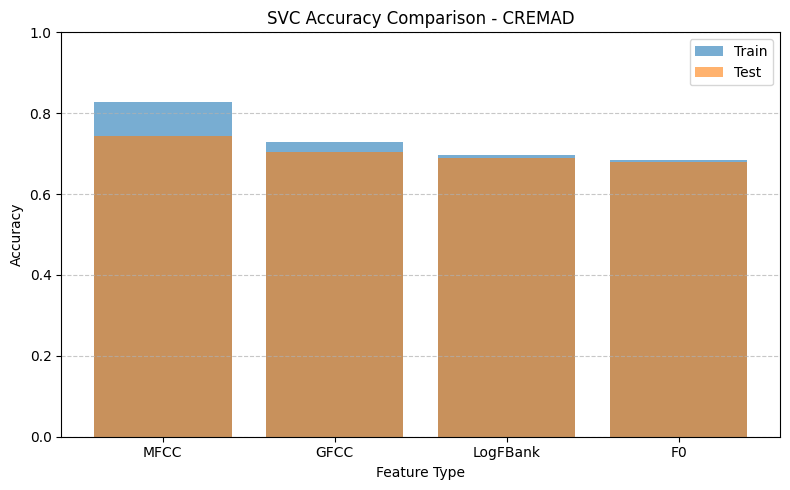

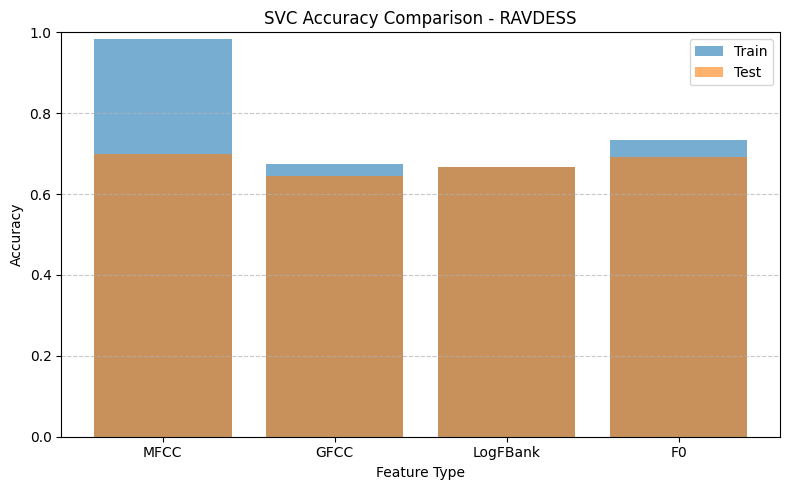

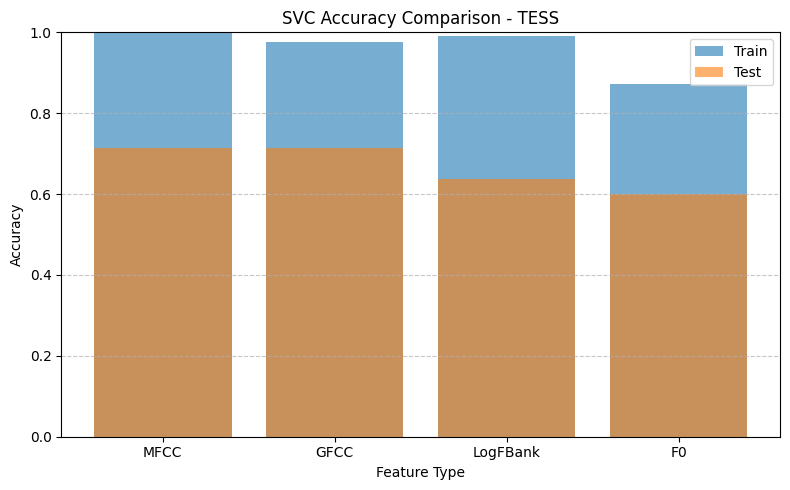

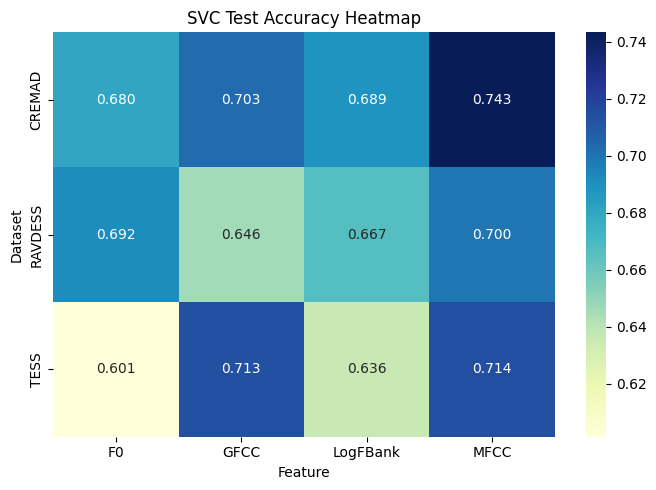


🏆 Best Feature per Dataset (SVC):
   Dataset Feature  Test Accuracy  \
0   CREMAD    MFCC       0.743231   
4  RAVDESS    MFCC       0.700000   
8     TESS    MFCC       0.714286   

                                         Best Params  
0  {'svc__C': 1, 'svc__gamma': 'auto', 'svc__kern...  
4  {'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel...  
8  {'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke...  


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---------------- Configuration ----------------
features = ["MFCC", "GFCC", "LogFBank", "F0"]
datasets = ["CREMAD", "RAVDESS", "TESS"]

# Hasil SVC
svc_results_dir = "../../Results/Predictions/SVC"
svc_tuning_dir = "../../Results/Tuning/SVC_Classifier"

# ---------------- Load SVC results ----------------
all_results = []
for dataset in datasets:
    for feat in features:
        result_path = os.path.join(svc_results_dir, f"{dataset}_{feat}_svc_results.npy")
        tune_path = os.path.join(svc_tuning_dir, f"{dataset}_{feat}_svc.npy")

        if not os.path.exists(result_path):
            print(f"⚠️ Result file not found: {result_path}")
            continue

        result = np.load(result_path, allow_pickle=True).item()
        tuning = np.load(tune_path, allow_pickle=True).item() if os.path.exists(tune_path) else None

        all_results.append({
            "Dataset": dataset,
            "Feature": feat,
            "Train Accuracy": result.get("train_acc", np.nan),
            "Test Accuracy": result.get("test_acc", np.nan),
            "Best Params": result.get("params", {}),
            "Best CV Accuracy": tuning.get("best_acc", np.nan) if tuning else np.nan,
        })

df_svc = pd.DataFrame(all_results)
print("\n📋 Ringkasan Hasil SVC:")
print(df_svc)

# ---------------- Visualization 1: Bar Chart per Dataset ----------------
for dataset in datasets:
    df_subset = df_svc[df_svc["Dataset"] == dataset]
    plt.figure(figsize=(8, 5))
    plt.bar(df_subset["Feature"], df_subset["Train Accuracy"], alpha=0.6, label="Train")
    plt.bar(df_subset["Feature"], df_subset["Test Accuracy"], alpha=0.6, label="Test")
    plt.title(f"SVC Accuracy Comparison - {dataset}")
    plt.xlabel("Feature Type")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

# ---------------- Visualization 2: Heatmap of Test Accuracy ----------------
pivot_table = df_svc.pivot(index="Dataset", columns="Feature", values="Test Accuracy")
plt.figure(figsize=(7, 5))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("SVC Test Accuracy Heatmap")
plt.tight_layout()
plt.show()

# ---------------- Visualization 3: Best Feature per Dataset ----------------
best_per_dataset = df_svc.loc[df_svc.groupby("Dataset")["Test Accuracy"].idxmax()]
print("\n🏆 Best Feature per Dataset (SVC):")
print(best_per_dataset[["Dataset", "Feature", "Test Accuracy", "Best Params"]])



📋 Ringkasan Hasil VGG16:
    Dataset   Feature  Test Accuracy  Precision    Recall  F1 Score  \
0    CREMAD      MFCC       0.654585   0.720292  0.654585  0.666559   
1    CREMAD      GFCC       0.611790   0.665678  0.611790  0.625028   
2    CREMAD  LogFBank       0.562445   0.651186  0.562445  0.576275   
3    CREMAD        F0       0.566812   0.652024  0.566812  0.580850   
4   RAVDESS      MFCC       0.685417   0.706672  0.685417  0.692067   
5   RAVDESS      GFCC       0.666667   0.444444  0.666667  0.533333   
6   RAVDESS  LogFBank       0.352083   0.676879  0.352083  0.212040   
7   RAVDESS        F0       0.427083   0.615564  0.427083  0.386963   
8      TESS      MFCC       0.683571   0.531780  0.683571  0.585770   
9      TESS      GFCC       0.714286   0.510204  0.714286  0.595238   
10     TESS  LogFBank       0.429286   0.552772  0.429286  0.452038   
11     TESS        F0       0.506429   0.742575  0.506429  0.504736   

                                          Best Par

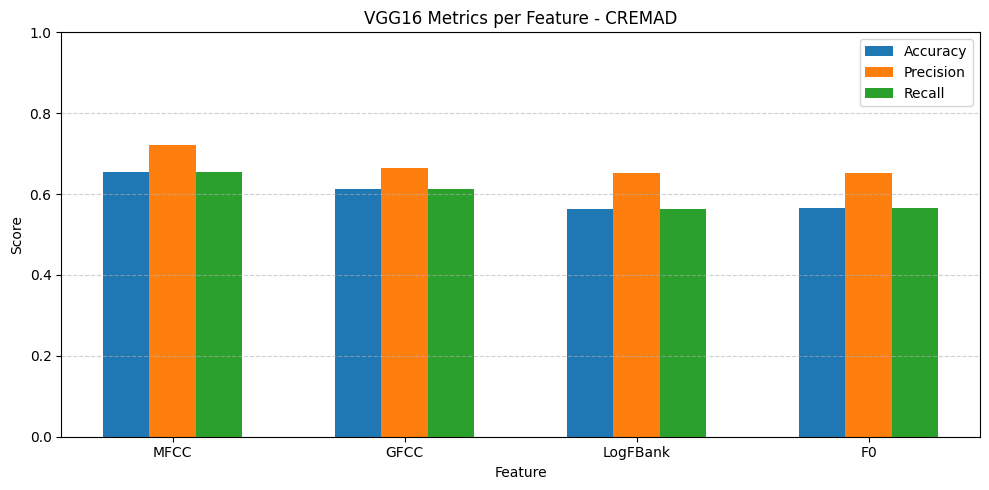

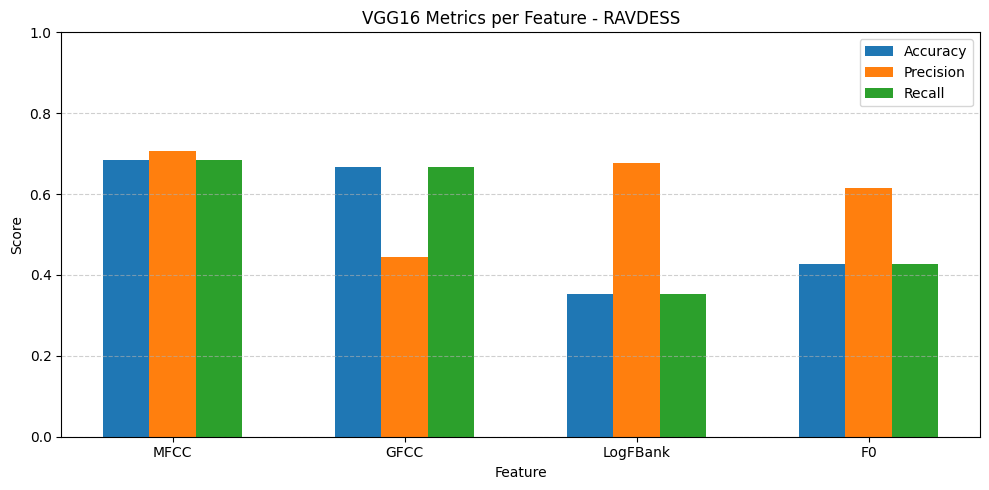

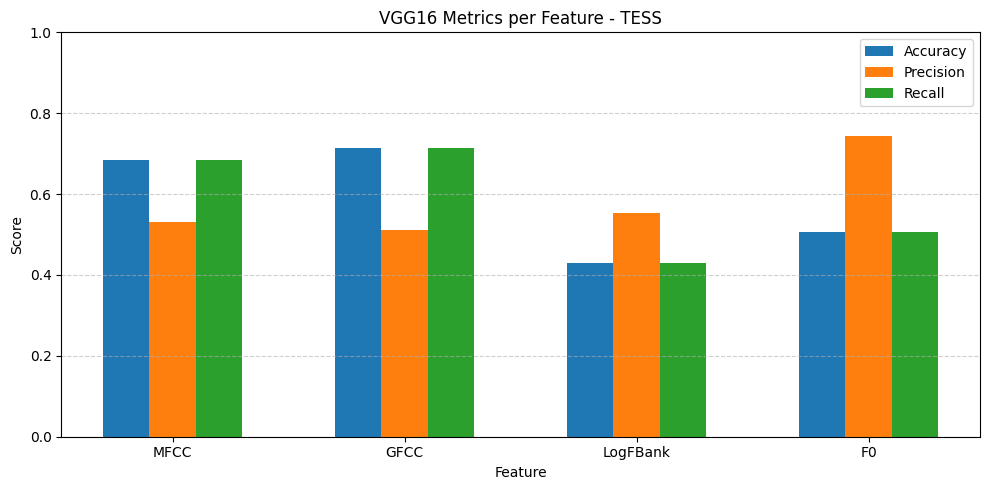

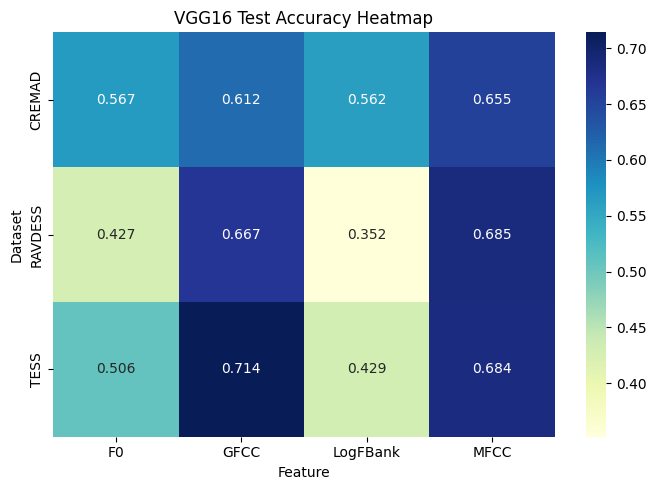

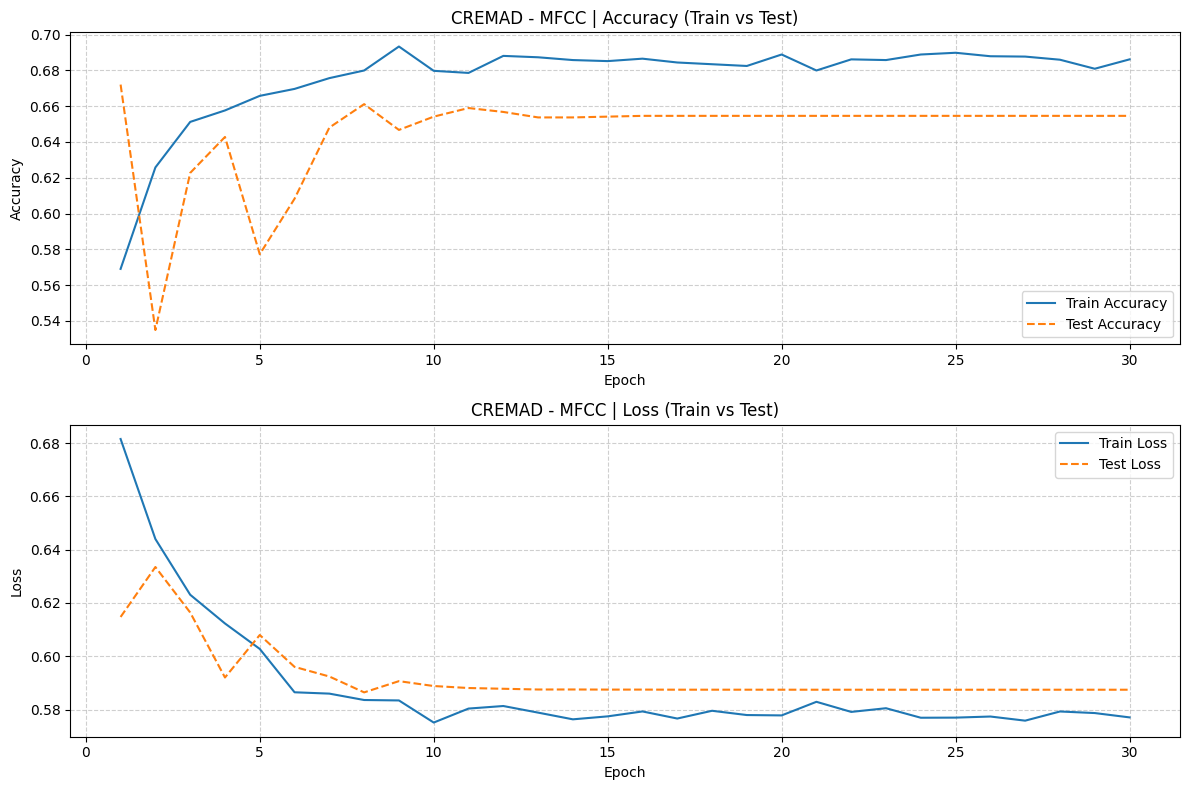

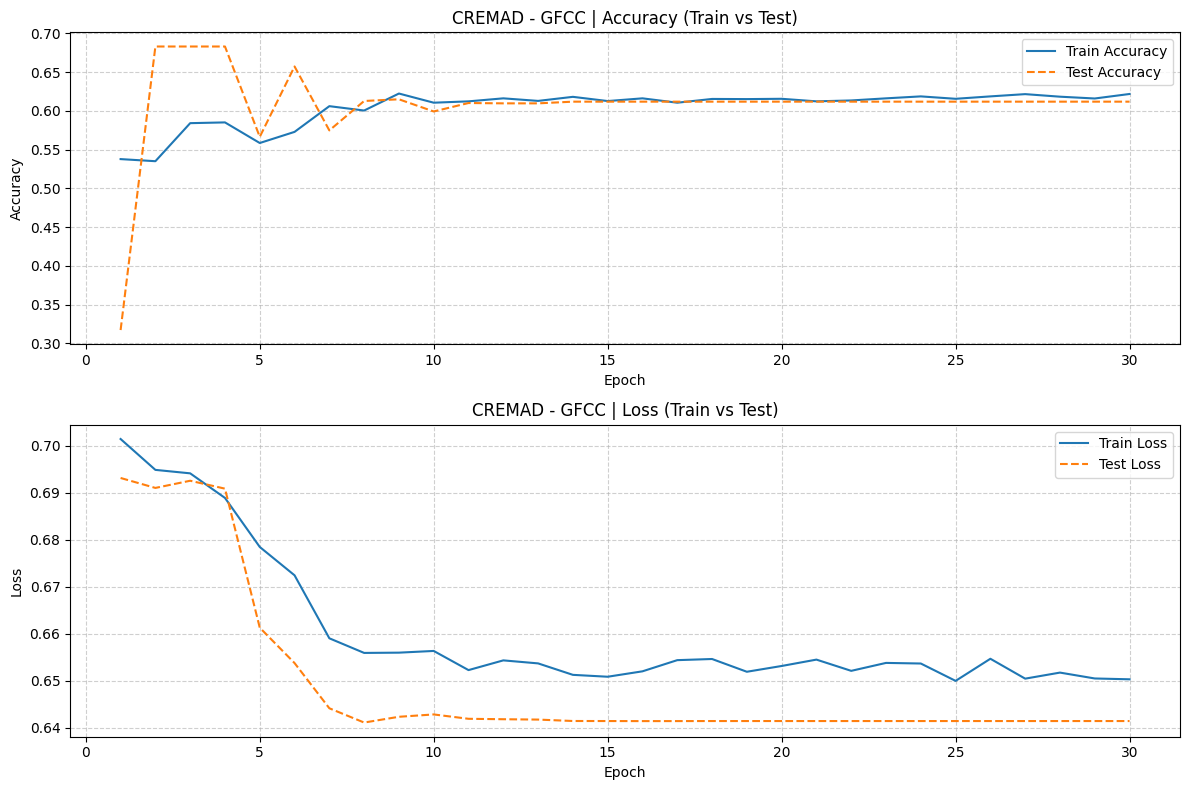

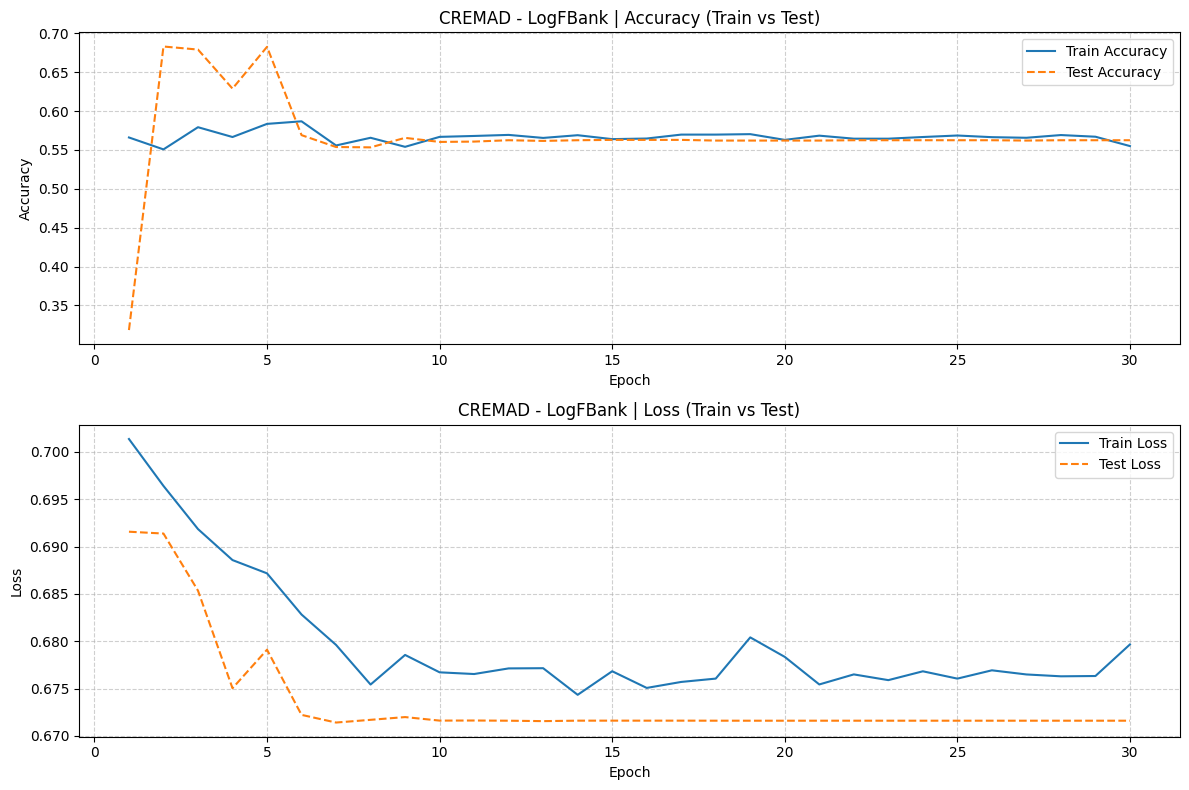

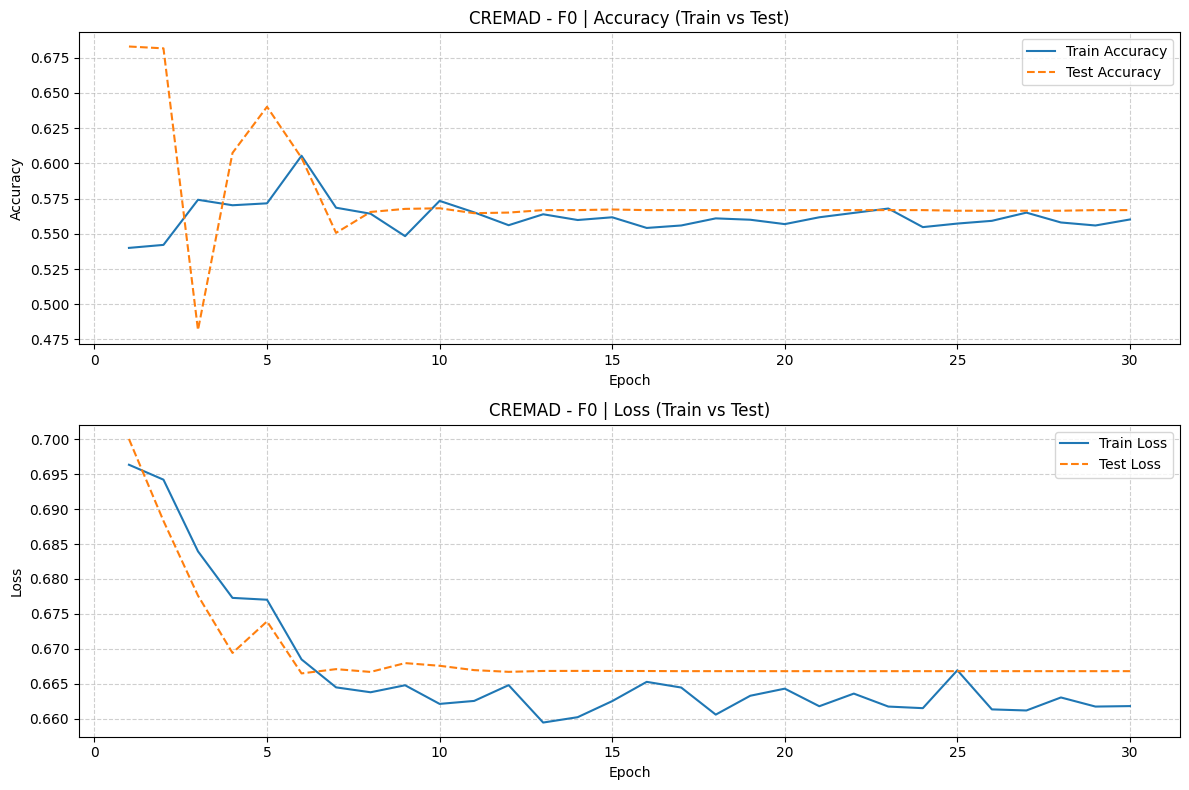

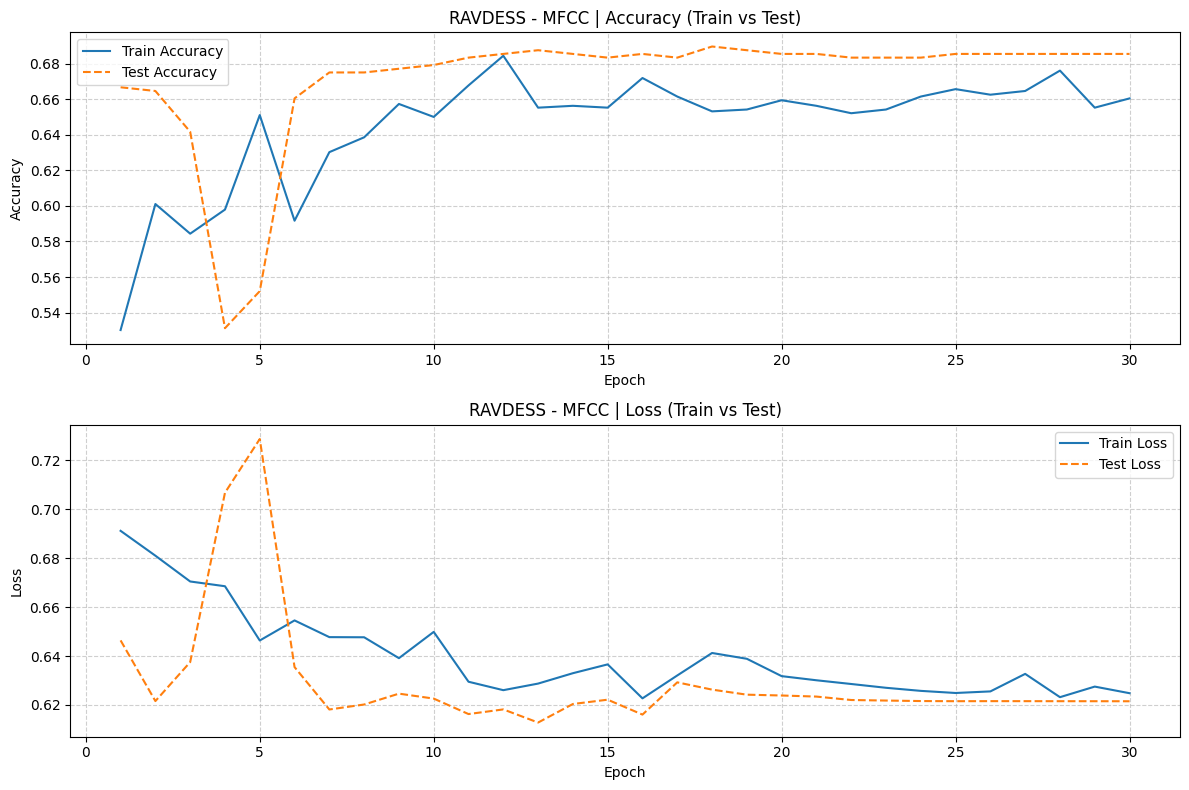

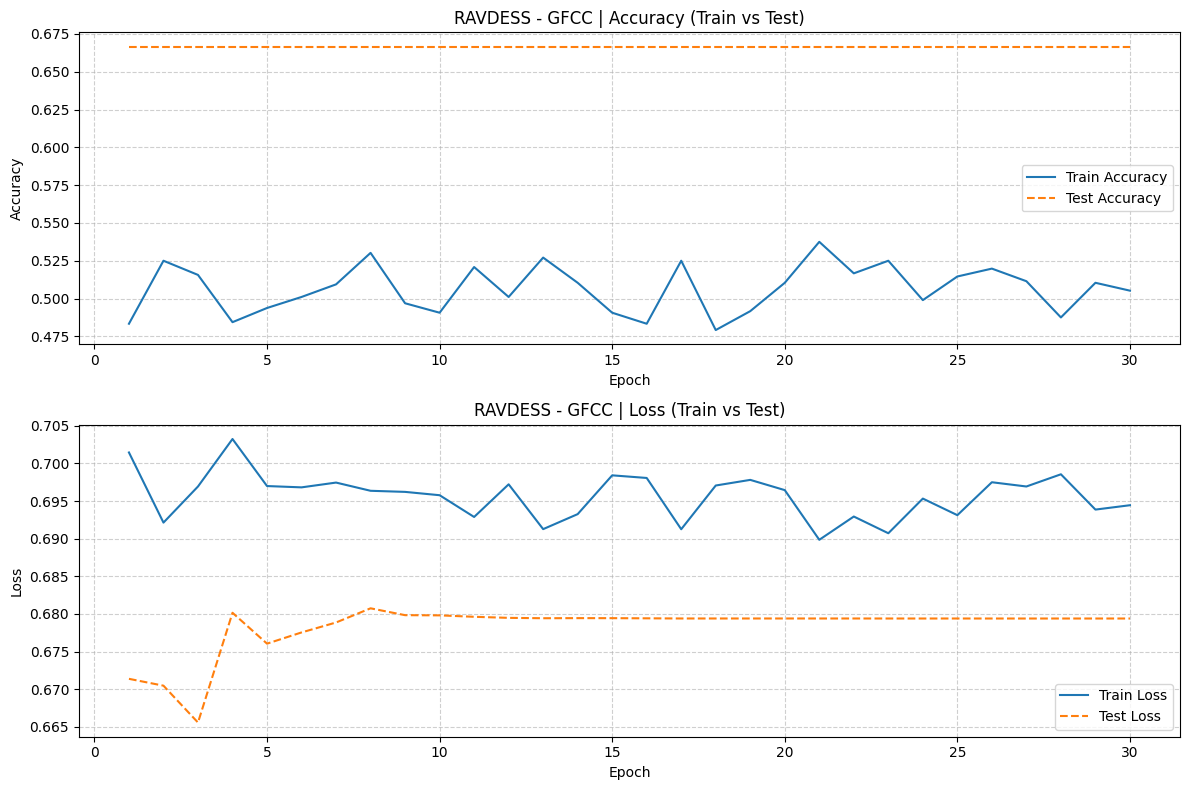

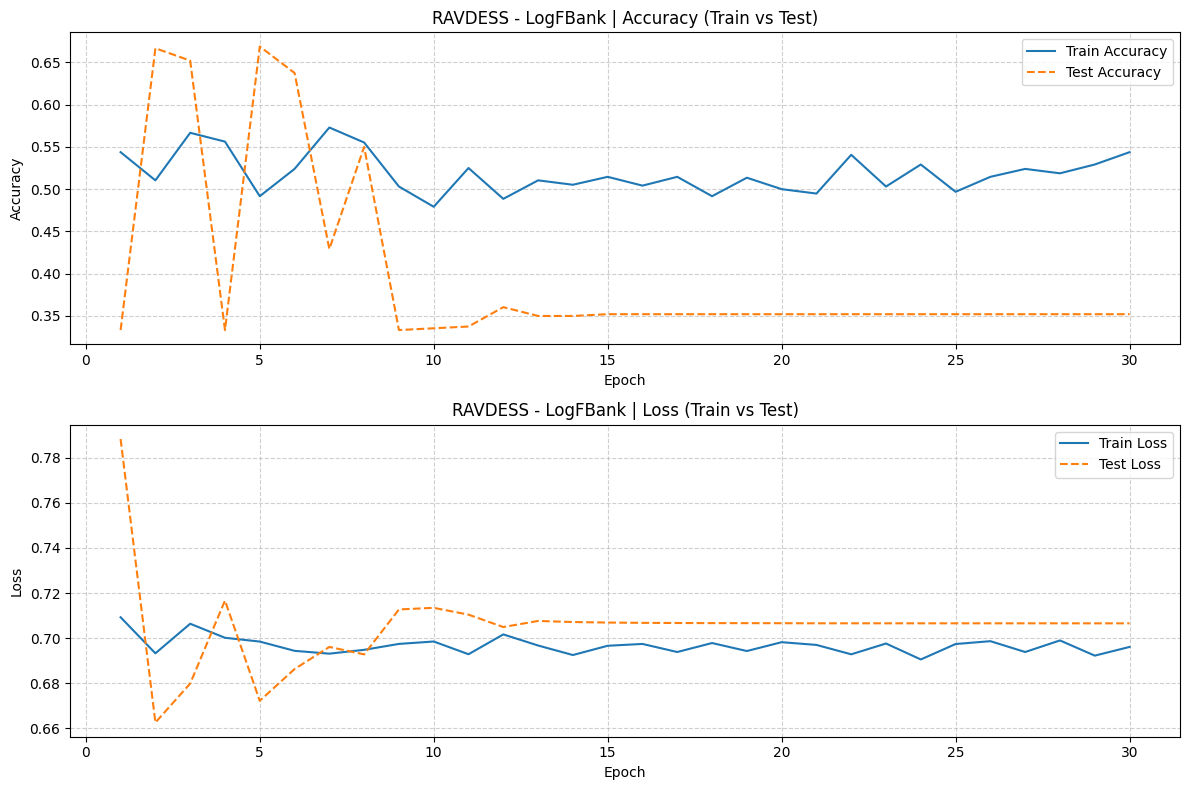

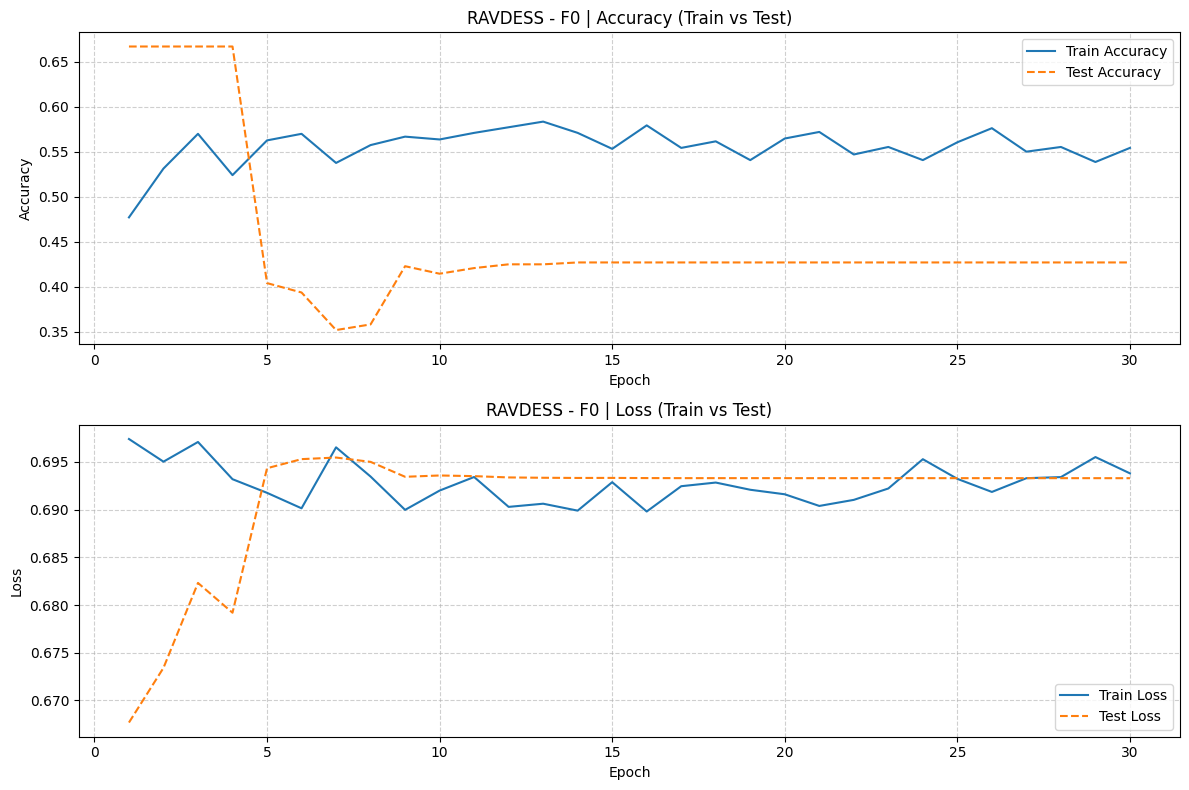

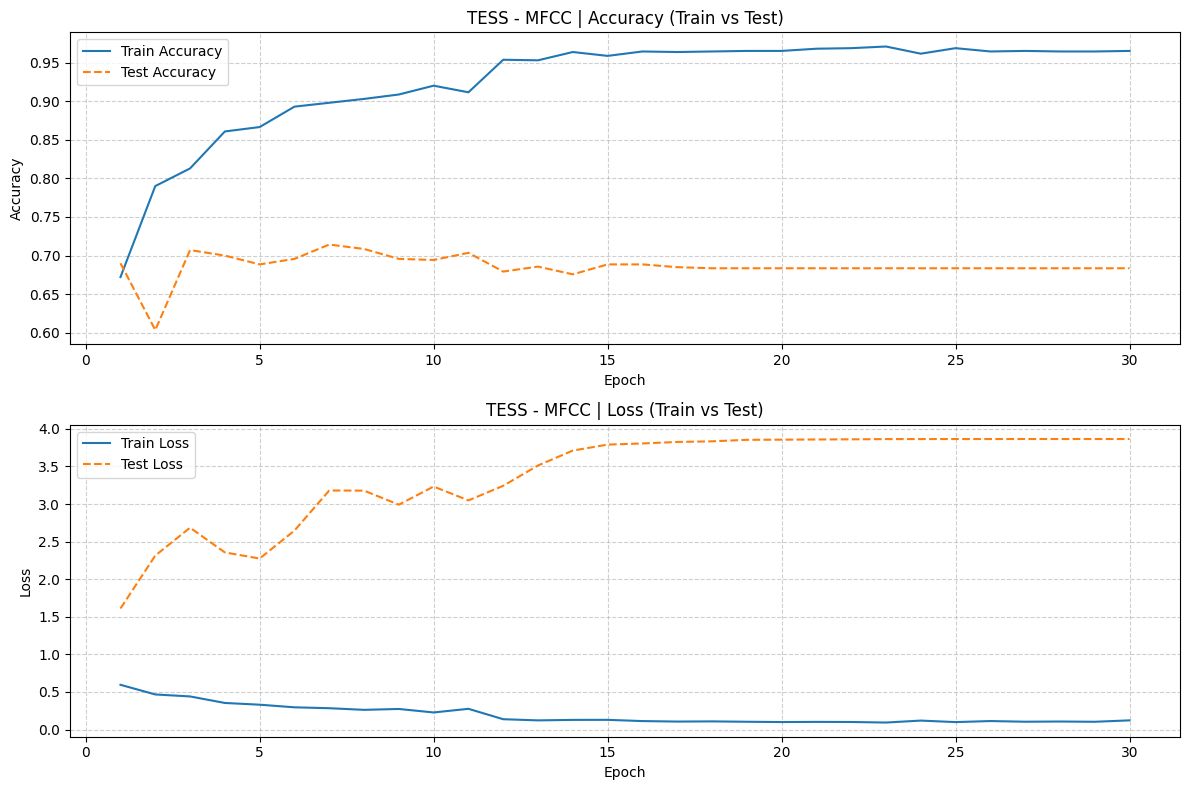

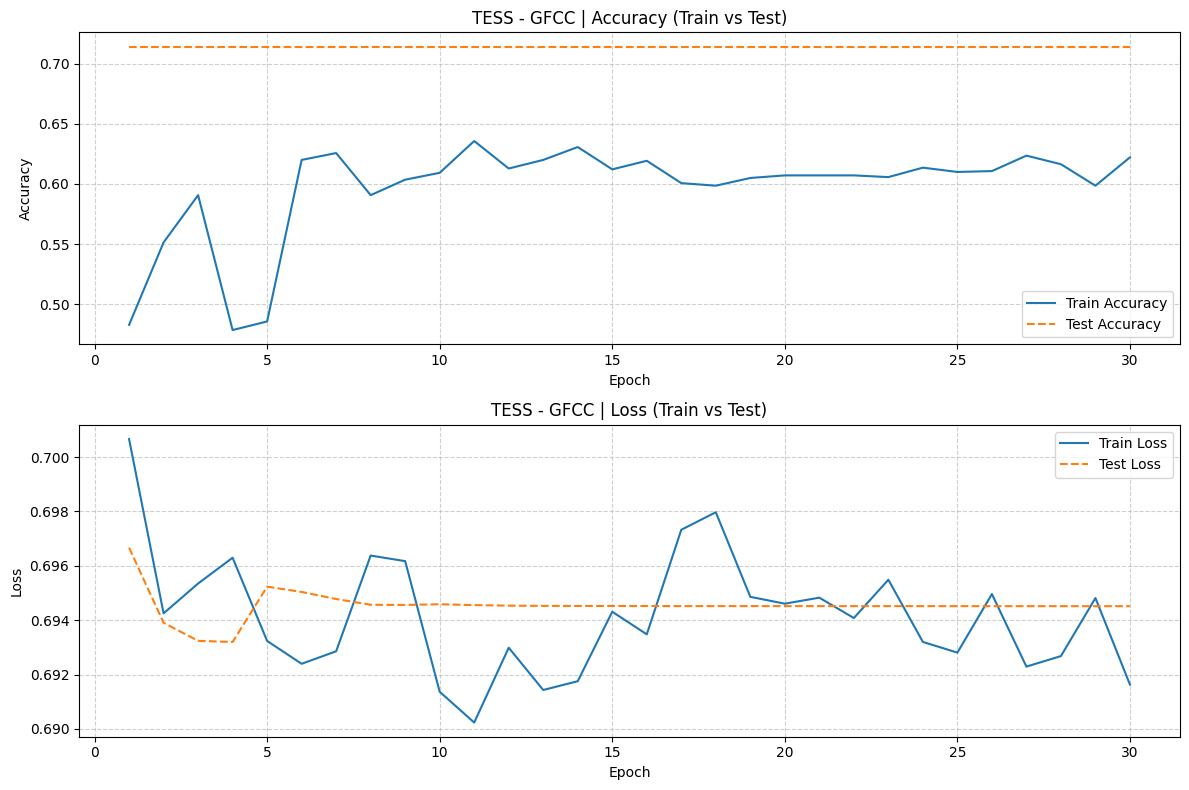

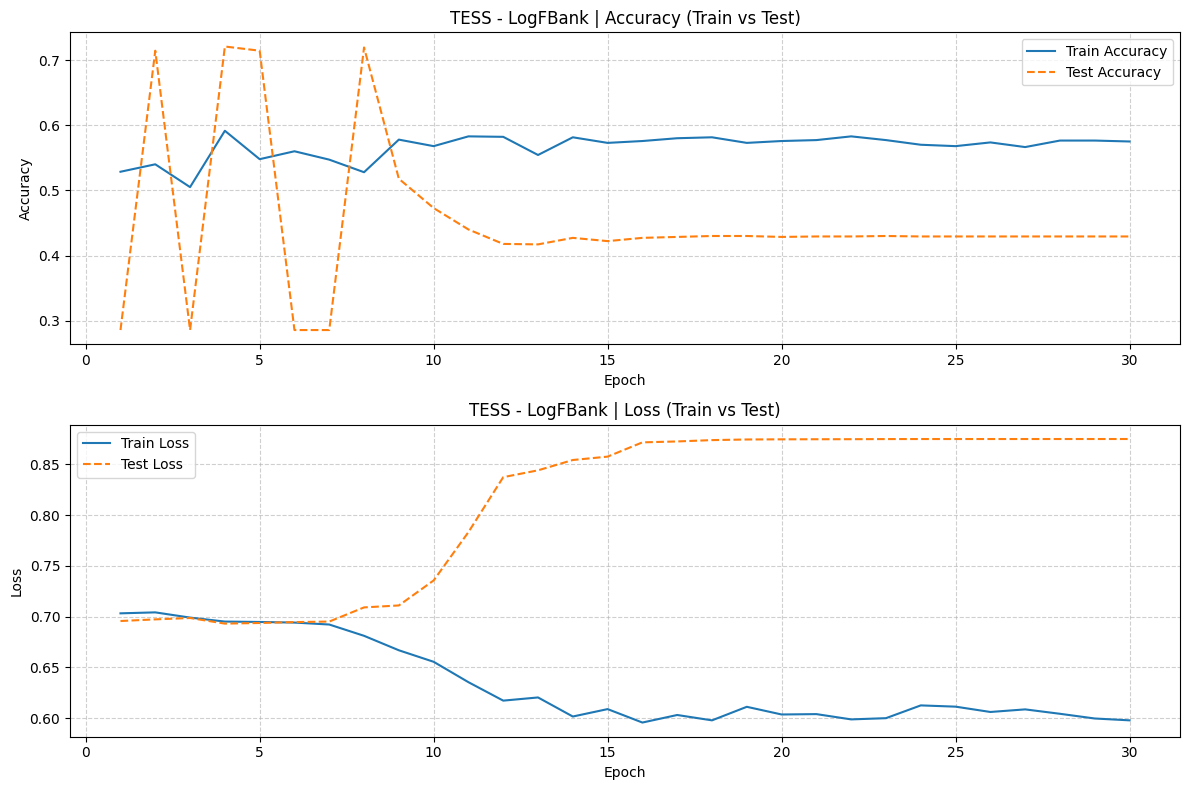

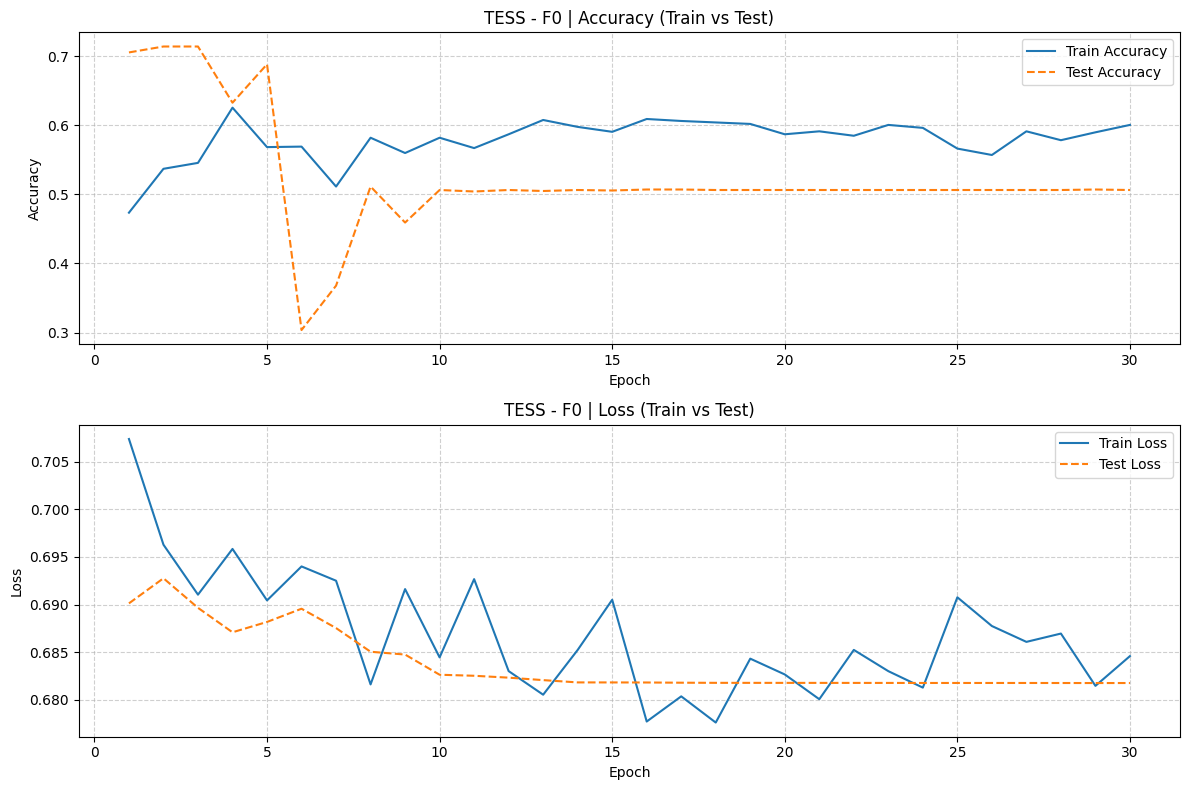


🏆 Best Feature per Dataset (VGG16):
   Dataset Feature  Test Accuracy  Precision    Recall  F1 Score  \
0   CREMAD    MFCC       0.654585   0.720292  0.654585  0.666559   
4  RAVDESS    MFCC       0.685417   0.706672  0.685417  0.692067   
9     TESS    GFCC       0.714286   0.510204  0.714286  0.595238   

                                         Best Params  
0  {'batch_size': 32, 'dropout_rate': 0.3, 'hidde...  
4  {'batch_size': 16, 'dropout_rate': 0.3, 'hidde...  
9  {'batch_size': 16, 'dropout_rate': 0.3, 'hidde...  


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---------------- Configuration ----------------
features = ["MFCC", "GFCC", "LogFBank", "F0"]
datasets = ["CREMAD", "RAVDESS", "TESS"]
vgg_results_dir = "../../Results/Predictions/VGG16_Improved"

# ---------------- Load All Results ----------------
all_results = []
history_dict = {}  # simpan history per dataset-feature

for dataset in datasets:
    for feat in features:
        result_path = os.path.join(vgg_results_dir, f"{dataset}_{feat}_vgg16_results.npy")
        if not os.path.exists(result_path):
            print(f"⚠️ Result file not found: {result_path}")
            continue

        result = np.load(result_path, allow_pickle=True).item()

        all_results.append({
            "Dataset": dataset,
            "Feature": feat,
            "Test Accuracy": result.get("test_metrics", {}).get("accuracy", np.nan),
            "Precision": result.get("test_metrics", {}).get("precision", np.nan),
            "Recall": result.get("test_metrics", {}).get("recall", np.nan),
            "F1 Score": result.get("test_metrics", {}).get("f1", np.nan),
            "Best Params": result.get("params", {})
        })

        history_dict[f"{dataset}_{feat}"] = result.get("history", {})

df_vgg = pd.DataFrame(all_results)
print("\n📋 Ringkasan Hasil VGG16:")
print(df_vgg)

# ---------------- Bar Chart per Dataset ----------------
for dataset in datasets:
    df_subset = df_vgg[df_vgg["Dataset"] == dataset]
    plt.figure(figsize=(10, 5))
    width = 0.2
    x = np.arange(len(df_subset))
    
    plt.bar(x - width, df_subset["Test Accuracy"], width=width, label="Accuracy")
    plt.bar(x, df_subset["Precision"], width=width, label="Precision")
    plt.bar(x + width, df_subset["Recall"], width=width, label="Recall")
    
    plt.xticks(x, df_subset["Feature"])
    plt.ylim(0, 1)
    plt.title(f"VGG16 Metrics per Feature - {dataset}")
    plt.xlabel("Feature")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# ---------------- Heatmap Test Accuracy ----------------
pivot_table = df_vgg.pivot(index="Dataset", columns="Feature", values="Test Accuracy")
plt.figure(figsize=(7, 5))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("VGG16 Test Accuracy Heatmap")
plt.tight_layout()
plt.show()

# ---------------- Plot Training vs Test History (Per Dataset) ----------------
for dataset in datasets:
    for feat in features:
        key = f"{dataset}_{feat}"
        history = history_dict.get(key, {})
        if not history:
            print(f"⚠️ No history found for {dataset}-{feat}")
            continue

        epochs = range(1, len(history.get("train_loss", [])) + 1)
        if len(epochs) == 0:
            print(f"⚠️ Empty history for {dataset}-{feat}")
            continue

        plt.figure(figsize=(12, 8))

        # --- Plot 1: Accuracy ---
        plt.subplot(2, 1, 1)
        plt.plot(epochs, history.get("train_acc", []), label="Train Accuracy")
        plt.plot(epochs, history.get("test_acc", []), '--', label="Test Accuracy")
        plt.title(f"{dataset} - {feat} | Accuracy (Train vs Test)")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)

        # --- Plot 2: Loss ---
        plt.subplot(2, 1, 2)
        plt.plot(epochs, history.get("train_loss", []), label="Train Loss")
        plt.plot(epochs, history.get("test_loss", []), '--', label="Test Loss")
        plt.title(f"{dataset} - {feat} | Loss (Train vs Test)")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)

        plt.tight_layout()
        plt.show()

# ---------------- Best Feature per Dataset ----------------
best_per_dataset = df_vgg.loc[df_vgg.groupby("Dataset")["Test Accuracy"].idxmax()]
print("\n🏆 Best Feature per Dataset (VGG16):")
print(best_per_dataset[["Dataset", "Feature", "Test Accuracy", "Precision", "Recall", "F1 Score", "Best Params"]])


In [10]:
df = pd.read_csv("..\..\Results\Tuning\cnn_results.csv")
df.head()

,feature,k1,k2,dropout1,dropout2,batch_size,lr,test_acc
0,MFCC,32,64,0.2,0.3,16,0.0100,68.750000
1,MFCC,32,64,0.2,0.3,16,0.0010,68.878866
2,MFCC,32,64,0.2,0.3,16,0.0001,68.363402
3,MFCC,32,64,0.2,0.3,32,0.0100,68.105670
4,MFCC,32,64,0.2,0.3,32,0.0010,59.536082


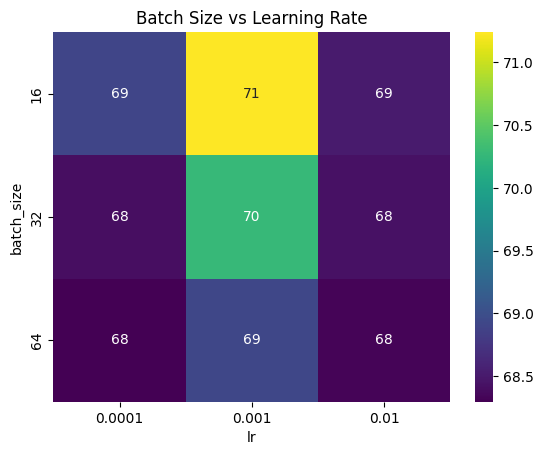

In [12]:
pivot = df.pivot_table(
    values="test_acc",
    index="batch_size",
    columns="lr"
)

sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("Batch Size vs Learning Rate")
plt.show()

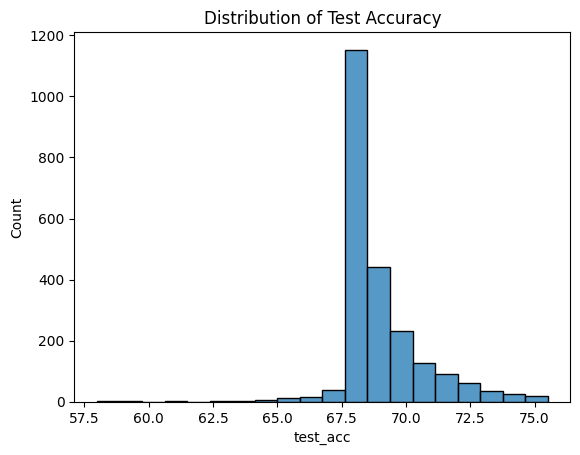

In [15]:
sns.histplot(df["test_acc"], bins=20)
plt.title("Distribution of Test Accuracy")
plt.show()

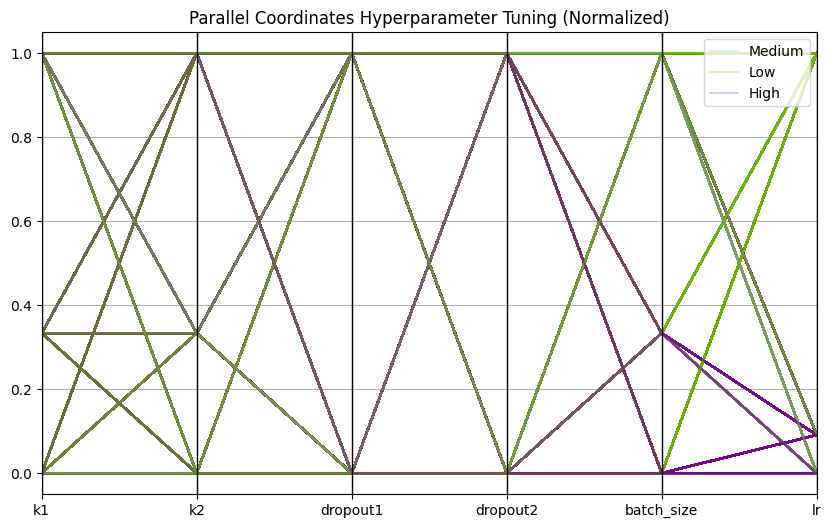

In [37]:
import pandas as pd
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# kolom hyperparameter
cols = ["k1","k2","dropout1","dropout2","batch_size","lr"]

# normalisasi
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[cols] = scaler.fit_transform(df[cols])

# buat kategori accuracy
df_scaled["acc_class"] = pd.qcut(df_scaled["test_acc"], q=3, labels=["Low","Medium","High"])

# plot
plt.figure(figsize=(10,6))
parallel_coordinates(
    df_scaled[["k1","k2","dropout1","dropout2","batch_size","lr","acc_class"]],
    "acc_class",
    alpha=0.2
)

plt.title("Parallel Coordinates Hyperparameter Tuning (Normalized)")
plt.show()

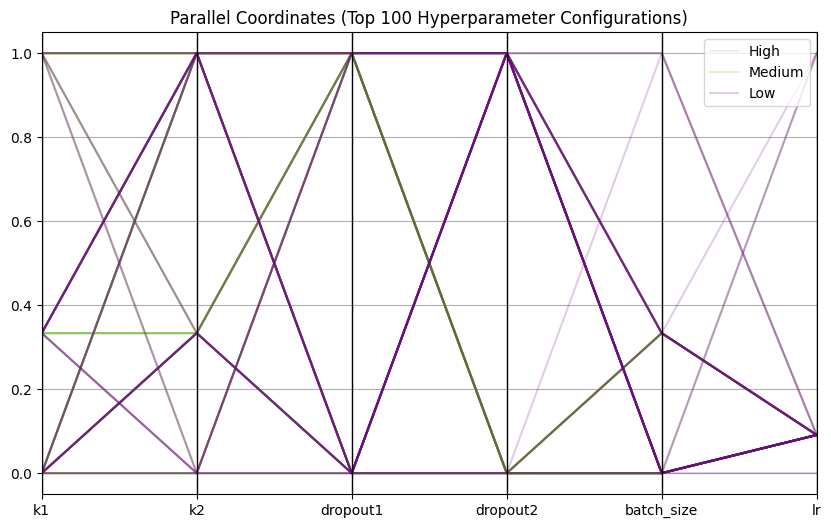

In [43]:
import pandas as pd
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

cols = ["k1","k2","dropout1","dropout2","batch_size","lr"]

# ambil top 100 eksperimen
df_top = df.sort_values("test_acc", ascending=False).head(100).copy()

# normalisasi
scaler = MinMaxScaler()
df_top[cols] = scaler.fit_transform(df_top[cols])

# kategori
df_top["acc_class"] = pd.qcut(df_top["test_acc"], q=3, labels=["Low","Medium","High"])

# plot
plt.figure(figsize=(10,6))
parallel_coordinates(
    df_top[cols + ["acc_class"]],
    "acc_class",
    alpha=0.2
)

plt.title("Parallel Coordinates (Top 100 Hyperparameter Configurations)")
plt.show()

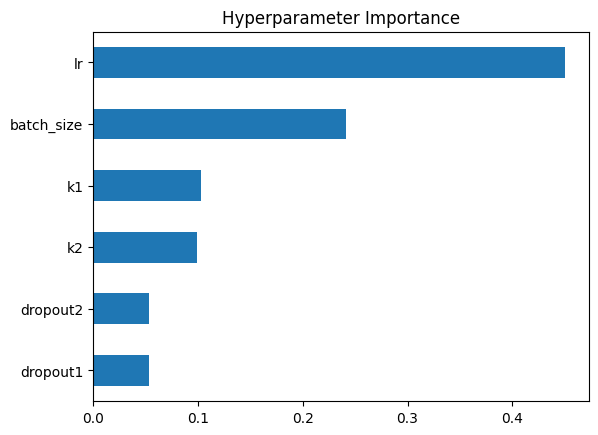

In [32]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

X = df[["k1","k2","dropout1","dropout2","batch_size","lr"]]
y = df["test_acc"]

model = RandomForestRegressor()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Hyperparameter Importance")
plt.show()

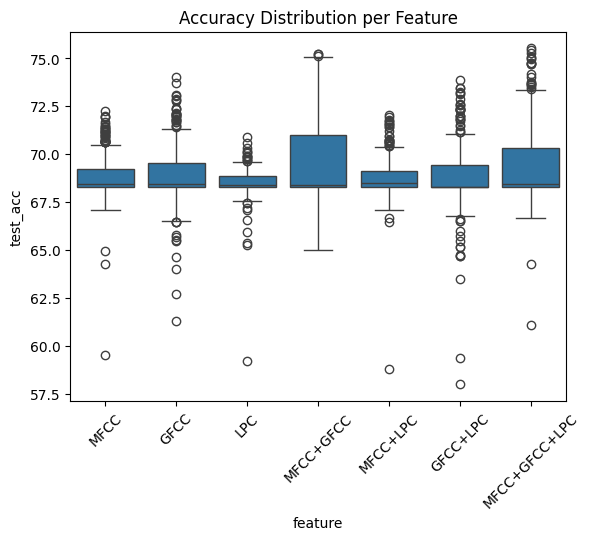

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="feature", y="test_acc")
plt.title("Accuracy Distribution per Feature")
plt.xticks(rotation=45)
plt.show()

In [26]:
ranking = df.groupby("feature")["test_acc"].max().sort_values(ascending=False)

print(ranking)

feature
MFCC+GFCC+LPC    75.515464
MFCC+GFCC        75.193299
GFCC             74.033505
GFCC+LPC         73.840206
MFCC             72.229381
MFCC+LPC         72.036082
LPC              70.876289
Name: test_acc, dtype: float64


In [27]:
ranking = df.groupby("feature")["test_acc"].mean().sort_values(ascending=False)

print(ranking)

feature
MFCC+GFCC        69.780928
MFCC+GFCC+LPC    69.497940
GFCC             68.929776
MFCC             68.867133
GFCC+LPC         68.847246
MFCC+LPC         68.810655
LPC              68.504797
Name: test_acc, dtype: float64


<Axes: xlabel='batch_size', ylabel='feature'>

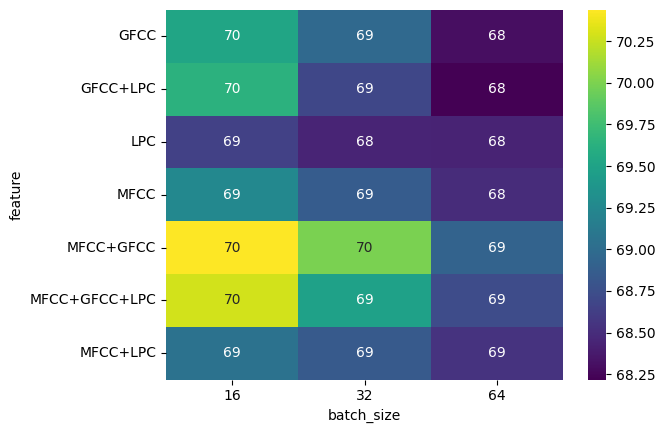

In [24]:
pivot = df.pivot_table(
    values="test_acc",
    index="feature",
    columns="batch_size"
)

sns.heatmap(pivot, annot=True, cmap="viridis")